In [2]:
#installation and set up
!pip install -U spacy
!python -m spacy download en
!ppip install -U scikit-learn numpy pandas

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/spacy/__main__.py", line 4, in <module>
    setup_cli()
  File "/opt/anaconda3/lib/python3.12/site-packages/spacy/cli/_util.py", line 77, in setup_cli
    command = get_command(app)
              ^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/typer/main.py", line 350, in get_command
    click_command: click.Command = get_group(typer_instance)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/typer/main.py", line 332, in get_group
    group = get_group_from_info(
            ^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/typer/main.py", line 483, in get_group_from_info
    command = get_command_from_info(
              ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packa

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
sns.set_theme(style="whitegrid")
from sklearn.model_selection import train_test_split

In [4]:
#Imports and Load Data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
train_df.head()

Training set shape: (3200, 2)
Test set shape: (800, 1)


,content,category
0,The senator announced new taxation policy today.,politics
1,Market shows improvement following economic in...,business
2,The senator announced new education policy today.,politics
3,CEO announces strategic changes in logistics o...,business
4,New film release breaks box office records.,entertainment


In [ ]:
#check missing values
print("\n--- Missing Values Check ---")
print("Train missing values:\n", train_df.isnull().sum())
print("Test missing values:\n", test_df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows in Train: {train_df.duplicated().sum()}")
print(f"Duplicate rows in Test: {test_df.duplicated().sum()}")


--- Missing Values Check ---
Train missing values:
 content     0
category    0
dtype: int64

Test missing values:
 content    0
dtype: int64

Duplicate rows in Train: 3048
Duplicate rows in Test: 665


Machine learning models usually require complete data.

In [6]:
train_df['category'].unique()
train_df['category'].value_counts()

category
politics         654
technology       652
sports           639
entertainment    631
business         624
Name: count, dtype: int64

<positron-console-cell-17>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



([0, 1, 2, 3, 4],
 [Text(0, 0, 'politics'),
  Text(1, 0, 'technology'),
  Text(2, 0, 'sports'),
  Text(3, 0, 'entertainment'),
  Text(4, 0, 'business')])

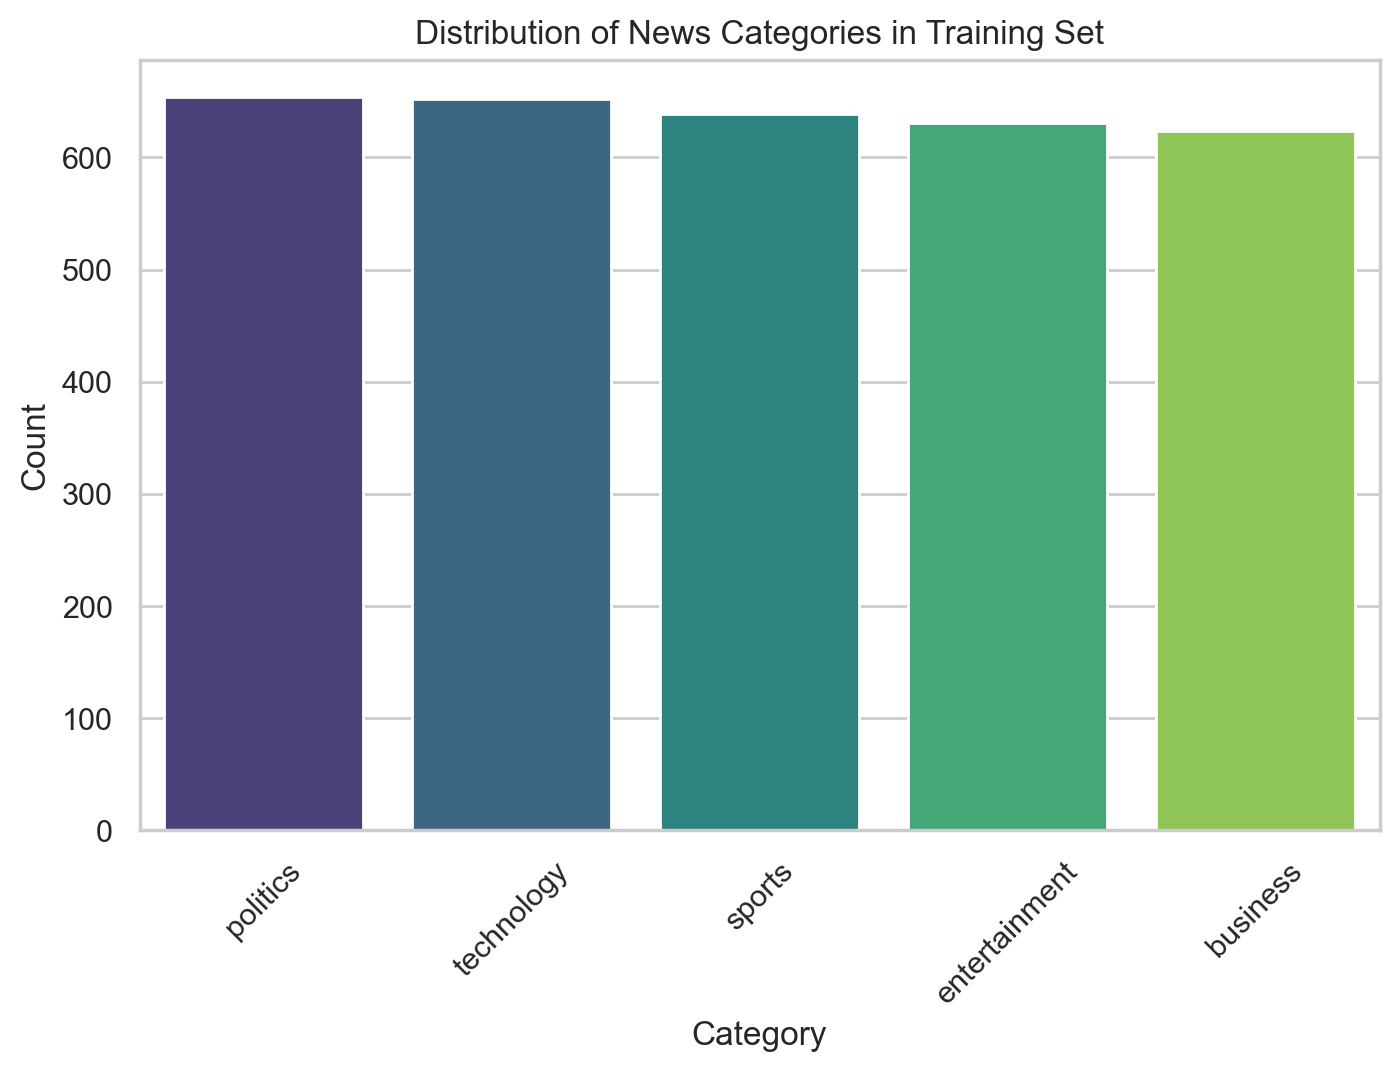

In [ ]:
# Class Distribution Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=train_df,
    x="category",
    order=train_df["category"].value_counts().index,
    palette="viridis",
)
plt.title("Distribution of News Categories in Training Set")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

In [11]:
print(f"Original training set shape: {train_df.shape}")
print("\nCategory distribution in full training set:")
print(train_df["category"].value_counts(normalize=True) * 100)

Original training set shape: (3200, 2)

Category distribution in full training set:
category
politics         20.43750
technology       20.37500
sports           19.96875
entertainment    19.71875
business         19.50000
Name: proportion, dtype: float64


In [15]:
#Perform Stratified Train/Validation Split
# test_size=0.2 means 80% for training and 20% for validation
train_data, val_data = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["category"]
)

print(f"\nNew Train split shape: {train_data.shape}")
print(f"New Validation split shape: {val_data.shape}")


New Train split shape: (2560, 2)
New Validation split shape: (640, 2)


In [16]:
# 4. Verify class proportions in both splits
print("\nTrain split category distribution (%):")
print(train_data["category"].value_counts(normalize=True) * 100)

print("\nValidation split category distribution (%):")
print(val_data["category"].value_counts(normalize=True) * 100)


Train split category distribution (%):
category
politics         20.429688
technology       20.390625
sports           19.960938
entertainment    19.726562
business         19.492188
Name: proportion, dtype: float64

Validation split category distribution (%):
category
politics         20.46875
technology       20.31250
sports           20.00000
entertainment    19.68750
business         19.53125
Name: proportion, dtype: float64


In [18]:
print(train_data['content'][0])

The senator announced new taxation policy today.


MODEL